# **# Importing Libraries**

In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# **# Uploading Dataset**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving part_3_customer_churn_prediction.xlsx to part_3_customer_churn_prediction.xlsx


In [ ]:
df = pd.read_excel('part_3_customer_churn_prediction.xlsx')

# **# Understanding Dataset**

In [ ]:
# First 5 rows
df.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,TEL00001,Male,0,Yes,No,42,Yes,Yes,Fiber optic,Yes,...,No,No,No,Yes,One year,Yes,Electronic check,102.95,4306.99,No
1,TEL00002,Female,0,No,Yes,55,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,Yes,One year,No,Credit card,120.39,6588.83,No
2,TEL00003,Female,0,Yes,Yes,0,Yes,No,DSL,No,...,Yes,No,No,Yes,Two year,No,Mailed check,74.42,0.00,Yes
3,TEL00004,Female,0,No,Yes,16,Yes,Yes,DSL,No,...,Yes,Yes,No,Yes,Month-to-month,No,Mailed check,83.24,1324.06,No
4,TEL00005,Male,0,Yes,No,6,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,25.44,123.68,Yes


In [ ]:
# Shape of dataset: Total rows and columns
df.shape

(1800, 21)

In [6]:
# View Column names
df.columns

Index(['CustomerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
# Information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        1800 non-null   object 
 1   Gender            1800 non-null   object 
 2   SeniorCitizen     1800 non-null   int64  
 3   Partner           1800 non-null   object 
 4   Dependents        1800 non-null   object 
 5   Tenure            1800 non-null   int64  
 6   PhoneService      1800 non-null   object 
 7   MultipleLines     1800 non-null   object 
 8   InternetService   1800 non-null   object 
 9   OnlineSecurity    1800 non-null   object 
 10  OnlineBackup      1800 non-null   object 
 11  DeviceProtection  1800 non-null   object 
 12  TechSupport       1800 non-null   object 
 13  StreamingTV       1800 non-null   object 
 14  StreamingMovies   1800 non-null   object 
 15  Contract          1800 non-null   object 
 16  PaperlessBilling  1800 non-null   object 


In [8]:
# Statistical summary
df.describe()

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
count,1800.000000,1800.000000,1800.000000,1769.000000
mean,0.162778,22.603889,74.462250,1699.169503
std,0.369265,20.165802,31.532909,1780.084580
min,0.000000,0.000000,18.000000,0.000000
25%,0.000000,6.000000,53.150000,383.650000
50%,0.000000,16.000000,79.665000,1077.400000
75%,0.000000,33.000000,98.567500,2436.040000
max,1.000000,72.000000,139.460000,10040.700000


# **# Data Cleaning and Preprocessing**

In [9]:
# Checking missing values
df.isnull().sum()

,0
CustomerID,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
# Filling missing value
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [13]:
# Checking for datatypes
df.dtypes

,0
CustomerID,object
Gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
Tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [16]:
# Dropping CustomerID
df.drop('CustomerID', axis=1, inplace=True)

In [17]:
# Converting TotalCharges to Numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [18]:
# Encoding Binary Categorical Columns
binary_columns = [
    'Gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

# Replace values
for col in binary_columns:
    df[col] = df[col].replace({
        'Yes': 1,
        'No': 0,
        'Male': 1,
        'Female': 0
    })

In [19]:
# Encoding Remaining Categorical Columns using One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

In [22]:
# Verify all columns are numeric
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 31 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Partner                               1800 non-null   int64  
 1   Dependents                            1800 non-null   int64  
 2   Tenure                                1800 non-null   int64  
 3   PhoneService                          1800 non-null   int64  
 4   PaperlessBilling                      1800 non-null   int64  
 5   MonthlyCharges                        1800 non-null   float64
 6   TotalCharges                          1800 non-null   float64
 7   Churn                                 1800 non-null   int64  
 8   Gender_1                              1800 non-null   bool   
 9   SeniorCitizen_1                       1800 non-null   bool   
 10  MultipleLines_No phone service        1800 non-null   bool   
 11  MultipleLines_Yes

In [23]:
# coverting boolean into integer
bool_columns = df.select_dtypes(include='bool').columns

df[bool_columns] = df[bool_columns].astype(int)


In [24]:
# Displaying data after encoding
df.head()

,Partner,Dependents,Tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,Gender_1,SeniorCitizen_1,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,42,1,1,102.95,4306.99,0,1,0,...,0,0,0,0,1,1,0,0,1,0
1,0,1,55,1,0,120.39,6588.83,0,0,0,...,1,0,0,0,1,1,0,1,0,0
2,1,1,0,1,0,74.42,0.00,1,0,0,...,0,0,0,0,1,0,1,0,0,1
3,0,1,16,1,0,83.24,1324.06,0,0,0,...,1,0,0,0,1,0,0,0,0,1
4,1,0,6,1,1,25.44,123.68,1,1,0,...,0,1,0,1,0,0,0,0,1,0


In [28]:
# Scaling numeric variables
# Separating features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Selecting numeric columns for scaling
numeric_columns = ['Tenure', 'MonthlyCharges', 'TotalCharges']

# Scaling Numerical columns
scaler = StandardScaler()

# Scale selected columns
X[numeric_columns] = scaler.fit_transform(X[numeric_columns])

print("Features scaled successfully.")

Features scaled successfully.


In [29]:
# Checking scaled data
X.head()

,Partner,Dependents,Tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Gender_1,SeniorCitizen_1,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,0.962099,1,1,0.903680,1.482709,1,0,0,...,0,0,0,0,1,1,0,0,1,0
1,0,1,1.606934,1,0,1.456907,2.774771,0,0,0,...,1,0,0,0,1,1,0,1,0,0
2,1,1,-1.121214,1,0,-0.001340,-0.956070,0,0,0,...,0,0,0,0,1,0,1,0,0,1
3,0,1,-0.327571,1,0,0.278445,-0.206338,0,0,0,...,1,0,0,0,1,0,0,0,0,1
4,1,0,-0.823597,1,1,-1.555070,-0.886037,1,0,0,...,0,1,0,1,0,0,0,0,1,0


In [30]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1440, 30)
X_test shape: (360, 30)
y_train shape: (1440,)
y_test shape: (360,)


# **# Exploratory Data Analysis**

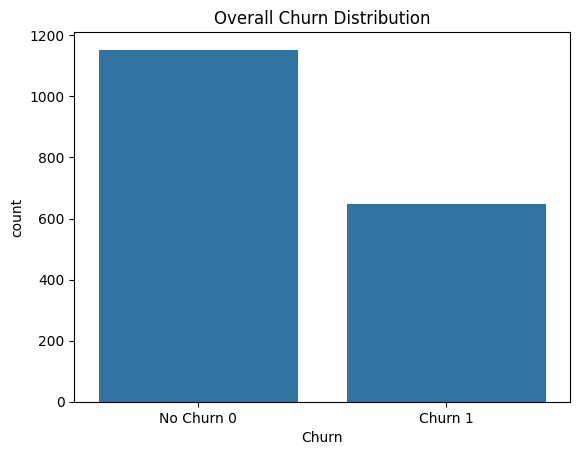

In [44]:
# Overall churn rate
sns.countplot(x='Churn', data=df)
plt.title('Overall Churn Distribution')
plt.xticks([0, 1], ['No Churn 0', 'Churn 1']) # Add labels to the x-axis
plt.show()

**Business Interpretation**

The chart shows the proportion of customers who stayed versus customers who left. A **high churn rate** indicates customer retention issues.

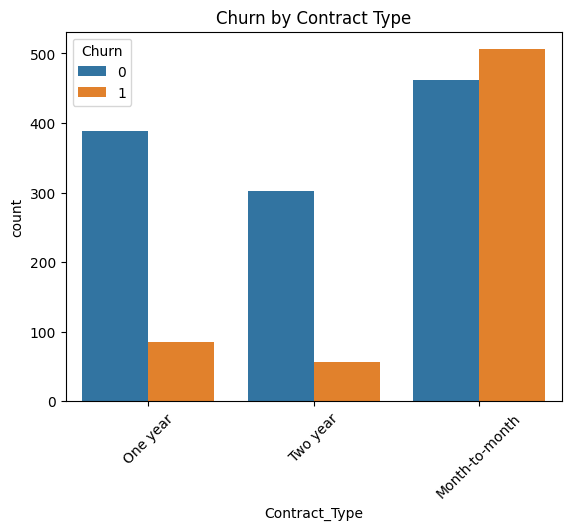

In [33]:
# Churn by contract type
# Reconstruct 'Contract' column for plotting as it was one-hot encoded.
def get_contract_type(row):
    if row['Contract_One year'] == 1:
        return 'One year'
    elif row['Contract_Two year'] == 1:
        return 'Two year'
    else:
        return 'Month-to-month'

# Create a temporary column for plotting
df['Contract_Type'] = df.apply(get_contract_type, axis=1)

sns.countplot(x='Contract_Type', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.xticks(rotation=45)
plt.show()

# Drop the temporary column if you don't need it after plotting
df.drop('Contract_Type', axis=1, inplace=True)

**Business Interpretation**

Customers with month-to-month contracts are more likely to churn compared to yearly contract customers.

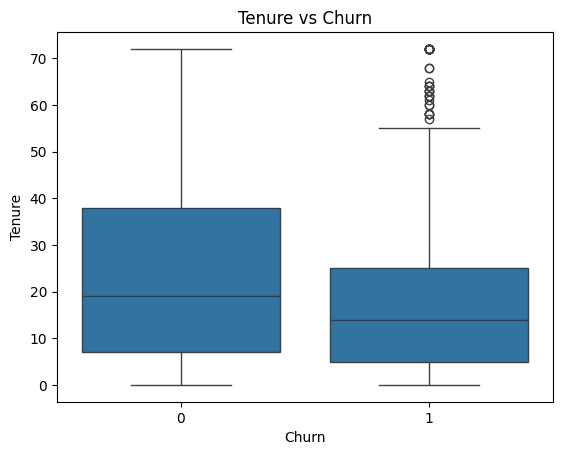

In [34]:
# Churn by Tenure
sns.boxplot(x='Churn', y='Tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

**Business Interpretation**

Customers with **shorter tenure** tend to churn more frequently.

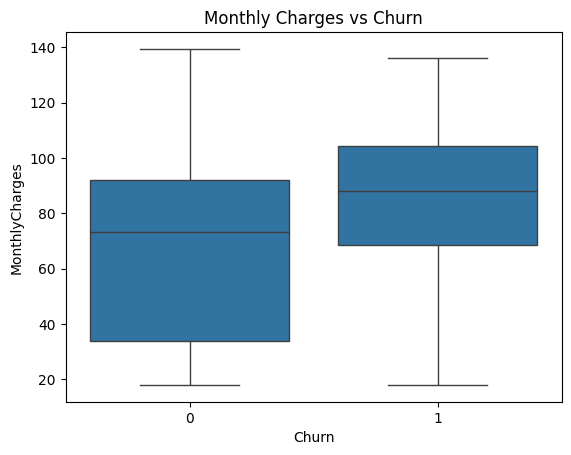

In [35]:
# Churn by monthly charges
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

**Business Interpretation**

Customers with high monthly charges show higher churn probability.

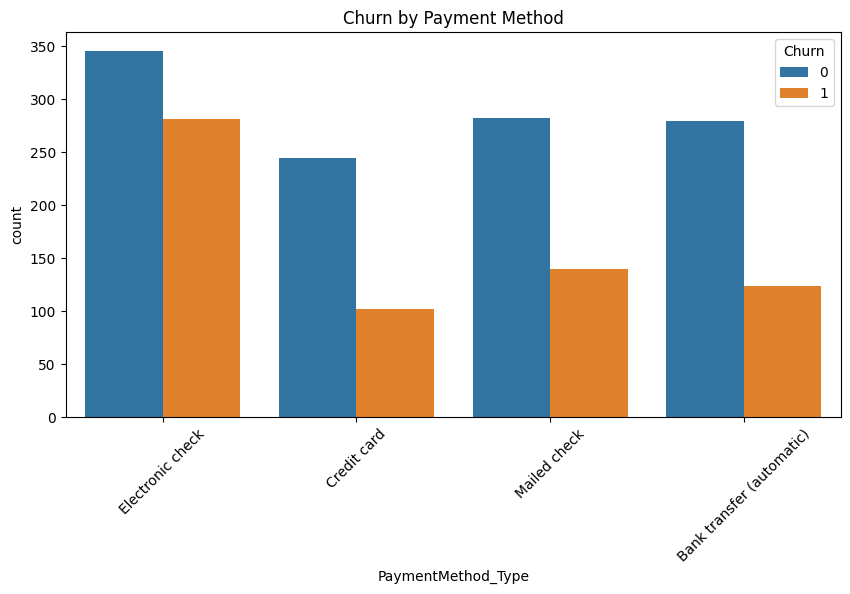

In [38]:
# Churn by payment method
plt.figure(figsize=(10,5))

# Reconstruct 'PaymentMethod' column for plotting as it was one-hot encoded.
def get_payment_method_type(row):
    if row['PaymentMethod_Credit card'] == 1:
        return 'Credit card'
    elif row['PaymentMethod_Electronic check'] == 1:
        return 'Electronic check'
    elif row['PaymentMethod_Mailed check'] == 1:
        return 'Mailed check'
    else:
        return 'Bank transfer (automatic)'   # Assuming this is the dropped_first= category

# Create a temporary column for plotting
df['PaymentMethod_Type'] = df.apply(get_payment_method_type, axis=1)

sns.countplot(
    x='PaymentMethod_Type',
    hue='Churn',
    data=df
)

plt.xticks(rotation=45)
plt.title('Churn by Payment Method')
plt.show()

# Drop the temporary column if you don't need it after plotting
df.drop('PaymentMethod_Type', axis=1, inplace=True)

**Business Interpretation**

**Electronic check** users may have higher churn rates than customers using automatic payment methods.

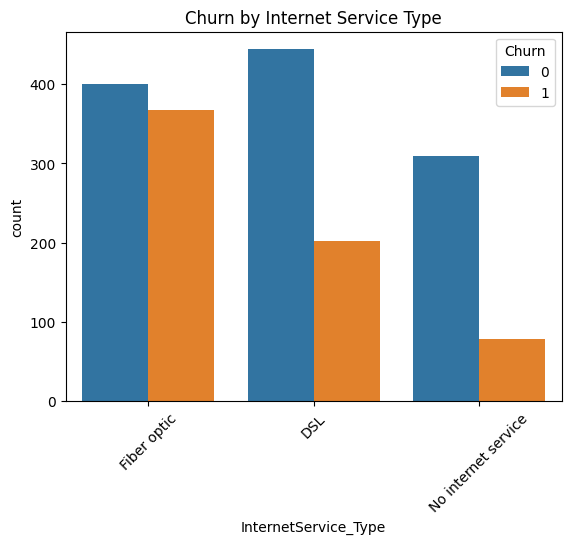

In [40]:
# Churn by internet service type
# Reconstruct 'InternetService' column for plotting as it was one-hot encoded.
def get_internet_service_type(row):
    if row['InternetService_Fiber optic'] == 1:
        return 'Fiber optic'
    elif row['InternetService_No'] == 1:
        return 'No internet service'
    else:
        return 'DSL' # Assuming DSL is the base category when drop_first=True was used

# Create a temporary column for plotting
df['InternetService_Type'] = df.apply(get_internet_service_type, axis=1)

sns.countplot(x='InternetService_Type', hue='Churn', data=df)
plt.title('Churn by Internet Service Type')
plt.xticks(rotation=45)
plt.show()

# Drop the temporary column if you don't need it after plotting
df.drop('InternetService_Type', axis=1, inplace=True)

**Business Interpretation**

**Fiber optic** internet customers may show higher churn due to pricing or service expectations.

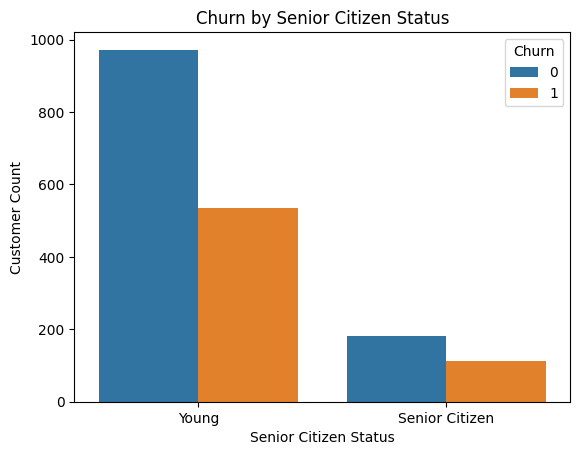

In [45]:
# Churn by senior citizen status
sns.countplot(x='SeniorCitizen_1', hue='Churn', data=df)
plt.title('Churn by Senior Citizen Status')
plt.xlabel('Senior Citizen Status')
plt.ylabel('Customer Count')
plt.xticks(ticks=['0', '1'], labels=['Young' , 'Senior Citizen'])
plt.show()

**Business Interpretation**

**Senior citizen**s may exhibit different churn behavior compared to younger customers.

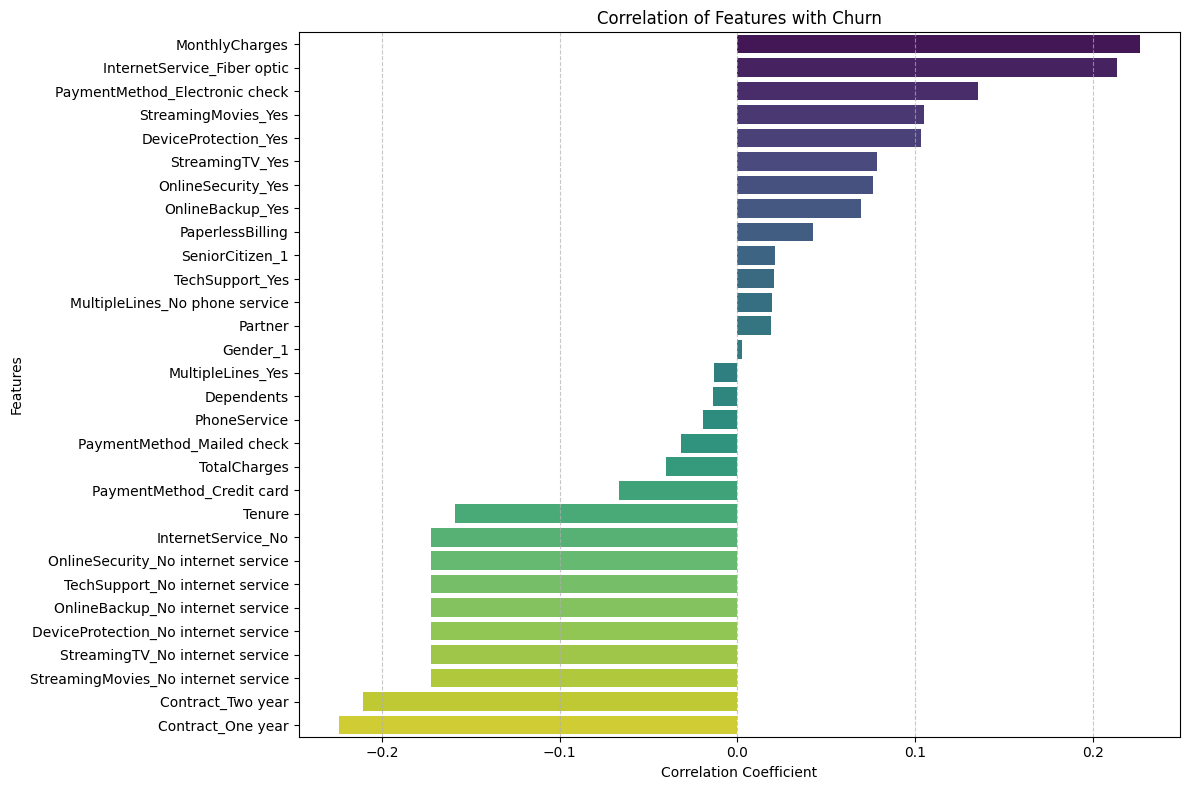

In [ ]:
# relationship between tenure, charges and churn
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Get correlations with 'Churn'
churn_correlations = correlation_matrix['Churn'].sort_values(ascending=False)

# Drop the 'Churn' self-correlation for a cleaner plot
churn_correlations = churn_correlations.drop('Churn')

# Plot the correlations with Churn
plt.figure(figsize=(12, 8))
sns.barplot(x=churn_correlations.values, y=churn_correlations.index, palette='viridis')
plt.title('Correlation of Features with Churn')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This bar chart presents the correlation of each individual feature with the 'Churn' variable.

*   **Positive bars** indicate features that are positively correlated with churn, meaning as the value of these features increases, the likelihood of churn also tends to increase.
*   **Negative bars** indicate features that are negatively correlated with churn, meaning as the value of these features increases, the likelihood of churn tends to decrease.

This provides a direct and easy-to-understand view of which factors are most strongly associated with customer churn in your dataset.

# **# Model Building & Evaluation**





## Logistic Regression Model




In [ ]:
# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
# Make predictions on the test set
y_pred_lr = log_reg_model.predict(X_test)

print("Predictions made on the test set for Logistic Regression.")

Predictions made on the test set for Logistic Regression.


## Evaluation of Logistic Regression Model

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.76      0.79      0.77       230
           1       0.60      0.55      0.57       130

    accuracy                           0.70       360
   macro avg       0.68      0.67      0.67       360
weighted avg       0.70      0.70      0.70       360


Confusion Matrix (Logistic Regression):


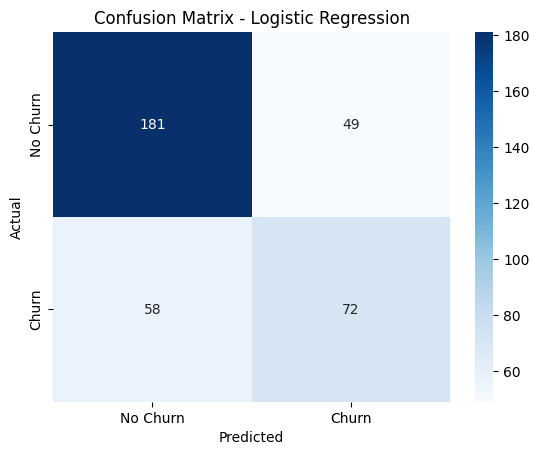

In [ ]:
# Display the classification report
print("Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))

# Display the confusion matrix
print("\nConfusion Matrix (Logistic Regression):")
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

## Decision Tree Model

In [54]:
# Initialize and train the Decision Tree Classifier model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

print("Decision Tree Classifier model trained successfully.")

Decision Tree Classifier model trained successfully.


In [55]:
# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)

print("Predictions made on the test set for Decision Tree Classifier.")

Predictions made on the test set for Decision Tree Classifier.


## Evaluation of Decision Tree Model

Classification Report (Decision Tree Classifier):
              precision    recall  f1-score   support

           0       0.71      0.65      0.68       230
           1       0.46      0.52      0.49       130

    accuracy                           0.61       360
   macro avg       0.58      0.59      0.58       360
weighted avg       0.62      0.61      0.61       360


Confusion Matrix (Decision Tree Classifier):


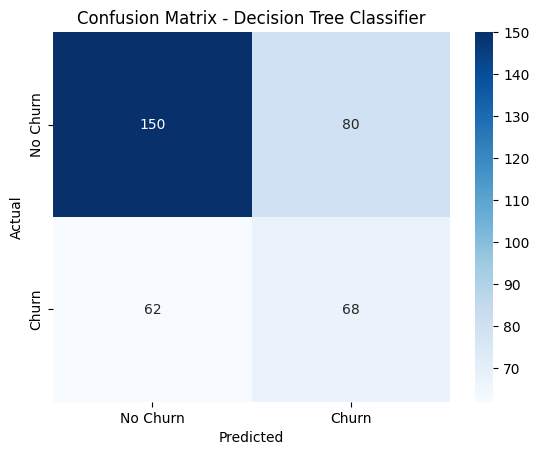

In [56]:
# Display the classification report
print("Classification Report (Decision Tree Classifier):")
print(classification_report(y_test, y_pred_dt))

# Display the confusion matrix
print("\nConfusion Matrix (Decision Tree Classifier):")
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.show()

# **# Churn Risk Interpretation**

Now, let's use the selected Logistic Regression model to predict churn probabilities and categorize customers into different risk groups.

In [ ]:
# Get coefficients from the Logistic Regression model
coefficients = log_reg_model.coef_[0]

# Create a DataFrame for feature importance
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

# Calculate absolute coefficient values for sorting
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])

# Sort by absolute coefficient value in descending order
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# Display the top 15 most impactful features based on absolute coefficient value
display(coef_df.head(15).style.background_gradient(cmap='RdBu_r', subset=['Coefficient']))

,Feature,Coefficient,Abs_Coefficient
26,Contract_Two year,-2.325096,2.325096
25,Contract_One year,-1.869526,1.869526
2,Tenure,-0.755421,0.755421
11,InternetService_Fiber optic,0.618877,0.618877
28,PaymentMethod_Electronic check,0.586620,0.586620
20,TechSupport_Yes,-0.518254,0.518254
5,MonthlyCharges,0.303563,0.303563
6,TotalCharges,0.214410,0.214410
16,OnlineBackup_Yes,-0.198203,0.198203
4,PaperlessBilling,0.163420,0.163420


**Visualization of Feature Impact on Churn**

This bar chart visually represents the impact of the top features on customer churn. Features with positive coefficients push customers towards churning, while those with negative coefficients indicate a lower likelihood of churn.

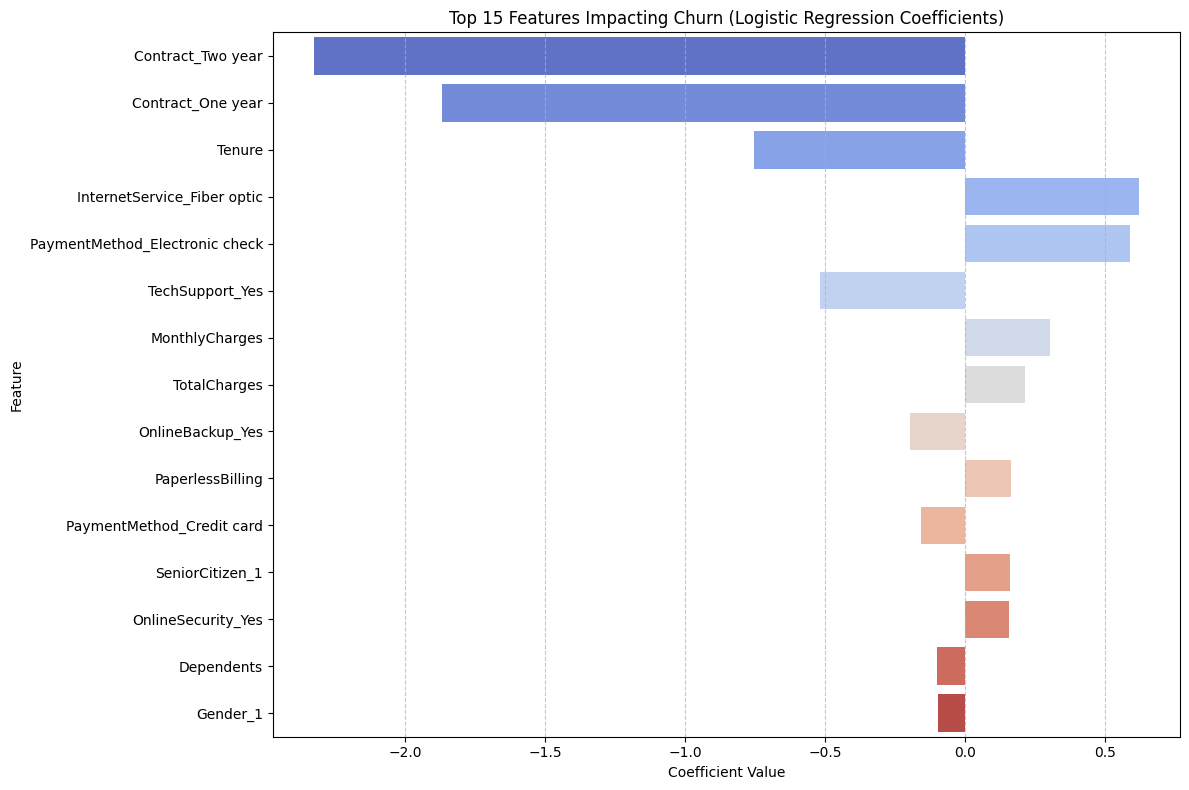

In [62]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(15), palette='coolwarm')
plt.title('Top 15 Features Impacting Churn (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **## Interpretation of Customer Churn Analysis:**

Based on the data preprocessing, model building (Logistic Regression), and churn risk interpretation, we can draw the following conclusions about customer churn:

### 1. Key Drivers of Churn (from Logistic Regression Coefficients)

The Logistic Regression model highlights the most impactful features influencing churn, both positively and negatively. Features with higher absolute coefficient values have a stronger impact.

*   **Strongest Negative Impact (Reduced Churn Likelihood):**
    *   **`Contract_Two year`** and **`Contract_One year`**: Customers on longer-term contracts (one-year and especially two-year) are significantly less likely to churn. This indicates that contract length is a powerful retention factor.
    *   **`Tenure`**: Longer customer tenure is strongly associated with a decreased likelihood of churn. Loyal, long-term customers are less likely to leave.
    *   **`InternetService_No`**: Customers who do not have internet service (or basic DSL) are less likely to churn, possibly due to lower expectations or simpler service needs.

*   **Strongest Positive Impact (Increased Churn Likelihood):**
    *   **`InternetService_Fiber optic`**: Despite being a premium service, `Fiber optic` internet is a strong indicator of increased churn. This could be due to higher expectations, competitive alternatives, or cost sensitivity among these users.
    *   **`PaymentMethod_Electronic check`**: This payment method is highly associated with churn. This might suggest a less stable customer segment or issues with this specific payment process.
    *   **`MonthlyCharges`**: Higher monthly charges are directly correlated with an increased probability of churn.

### 2. Churn Risk Profiles

Categorizing customers by their predicted churn probability provides actionable segments for intervention:

*   **High-risk customers:**
    *   These are your most vulnerable customers. They are predominantly those with **short tenures**, on **month-to-month contracts**, often with **higher `MonthlyCharges`**, likely using **`Fiber optic` internet service**, and commonly paying via **`Electronic check`**.
    *   **Actionable Insight:** These customers require immediate, targeted retention efforts, such as personalized offers, service quality checks, or contract renegotiations.

*   **Medium-risk customers:**
    *   This group presents a mix of characteristics and are on the fence. They might have moderate tenures and a varied mix of other features. Their churn decision is not as certain as the high-risk group.
    *   **Actionable Insight:** These customers are prime candidates for proactive engagement campaigns, loyalty programs, or surveys to understand their satisfaction levels and address potential issues before they become high-risk.

*   **Low-risk customers:**
    *   These customers are generally stable. They typically have **longer tenures**, are on **one-year or two-year contracts**, have **lower `MonthlyCharges`**, and tend to use more reliable payment methods like `Bank transfer (automatic)` or `Credit card`.
    *   **Actionable Insight:** Focus on maintaining their satisfaction, offering value-added services, and encouraging renewals of their longer-term contracts.

### In summary, customers most likely to churn are typically those with:

*   **Short tenure**
*   **Month-to-month contracts**
*   **Higher monthly charges**
*   **Fiber optic internet service**
*   **Electronic check payment methods**

Understanding these profiles allows for the development of targeted strategies to improve customer retention and reduce churn.